# Load Imports

In [114]:
from __future__ import annotations
import os
import sys
import copy
import pandas as pd
import numpy as np
import logging
import random
import requests
import pyarrow.parquet as pq

from pathlib import Path, PurePath

# Configure logging
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s [%(levelname)s] %(message)s")

# Suppress warnings
# logging.getLogger('safety_events').setLevel(logging.WARNING)

# Data quality profiling 
from ydata_profiling import ProfileReport

# Date and Time
import datetime
from datetime import datetime, timezone


# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.path import Path as MplPath
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "notebook_connected"

# Geo
from ipyleaflet import Map, Marker, MarkerCluster, basemaps
from ipywidgets import Dropdown, DatePicker, HBox, VBox, HTML, Output, Label, Layout

# Notebook Utilities
from IPython.display import display, Image, JSON
from tqdm import tqdm

# Duckdb
import duckdb


from typing import Sequence, Iterable, List, Optional, Tuple
from dataclasses import dataclass

# Preprocessing imports
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Baseline pipelines
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, max_error


import matplotlib.pyplot as plt

In [2]:
# Manually set dir if things go awry
os.chdir('C:\\Users\\lover\\Documents\\GitHub\\predicting-safety-events-US-cities-base')

DATA_PATH = None
# Use explicit DATA_PATH, otherwise use relative dir to infer location
#DATA_PATH = PurePath('C:\\Users\\lover\\Documents\\GitHub\\Spotify_Listening_History_Analysis\\data')

# Get current path
cwd = PurePath(Path.cwd())

# Use conditional to ensure we do not traverse to higher level dir.
if not DATA_PATH:
    # Change current working directory from `notebooks` directory to one level above.
    os.chdir('..')    
    
    # Construct path to archive location
    DATA_PATH = cwd / 'data'
    
# Construct query output path
# QUERY_OUTPUT_PATH = cwd / 'data'/ 'sql' / 'query_results'

# Confirm location where data files are stored.
logging.info(str(DATA_PATH))

2026-01-10 00:14:12,179 [INFO] C:\Users\lover\Documents\GitHub\predicting-safety-events-US-cities-base\data


# Load Dataset

In [3]:
# Load parquet file into dataframe
sf_dataframe = pd.read_parquet(DATA_PATH / 'safety-SanFrancisco-2.parquet')
sf_dataframe.head()

,requestId,dataSubtype,dateTime,category,subcategory,status,address,latitude,longitude,source,neighborhood
0,1,911_Fire,2018-10-02 11:54:01,Potentially Life-Threatening,Medical Incident,NaN,ELM ST/FRANKLIN ST,37.781286,-122.422187,NaN,Tenderloin
1,2,311_All,2018-07-08 15:00:27,Street and Sidewalk Cleaning,Bulky Items,Closed,"1536 SACRAMENTO ST, SAN FRANCISCO, CA, 94109",37.791887,-122.418188,Mobile/Open311,Nob Hill
2,3,311_All,2016-06-28 13:12:28,General Request - COUNTY CLERK,customer_callback,Closed,Not associated with a specific address,0.000000,0.000000,Phone,Unknown
3,7,311_All,2017-03-03 09:34:49,Temporary Sign Request,Temporary Sign Request for Other_Event_Type,Closed,"2190 NORTH POINT ST, SAN FRANCISCO, CA, 94123",37.802853,-122.443245,Phone,Marina
4,10,911_Fire,2016-10-25 18:33:20,Potentially Life-Threatening,Medical Incident,NaN,200 Block of DALEWOOD WAY,37.737953,-122.456498,NaN,Portola


In [4]:
sf_dataframe.dtypes

requestId                int64
dataSubtype           category
dateTime        datetime64[ns]
category              category
subcategory           category
status                category
address                 object
latitude               float64
longitude              float64
source                category
neighborhood            object
dtype: object

# Data Preparation and Aggregation

In [5]:
sf_dataframe['category'].unique()

['Potentially Life-Threatening', 'Street and Sidewalk Cleaning', 'General Request - COUNTY CLERK', 'Temporary Sign Request', 'Fire', ..., 'General Request - CITY ATTORNEY', 'General Request - PUBLIC DEFENDER', 'General Request - ADULT PROBATION', 'General Request - GRANTS FOR THE ARTS', 'General Request - CONVENTION FACILITIES']
Length: 96
Categories (95, object): ['311 External Request', 'Abandoned Vehicle', 'Alarm', 'Blocked Street or SideWalk', ..., 'Street and Sidewalk Cleaning', 'Streetlights', 'Temporary Sign Request', 'Tree Maintenance']

There are 95 different categories! Dafuuuq.

> We will create one model per event category, starting with “Potentially Life-Threatening” events.


In [15]:
duckdb.sql("""
SELECT 
    category
    ,neighborhood
    --,COUNT(category) AS count
FROM sf_dataframe
GROUP BY category
ORDER BY count DESC
LIMIT 5
""")

BinderException: Binder Error: Referenced column "count" not found in FROM clause!
Candidate bindings: "longitude", "source", "category", "requestId", "subcategory"

In [ ]:
duckdb.sql("""
SELECT 
    DISTINCT category
    ,COUNT(category) AS count
FROM sf_dataframe
WHERE category = 'Potentially Life-Threatening'
GROUP BY category
ORDER BY count DESC
LIMIT 5
""")

In [23]:
pot_life_threatening = duckdb.sql("""
SELECT * 
FROM sf_dataframe
WHERE category = 'Potentially Life-Threatening'
AND dateTime BETWEEN '2016-01-01' AND '2020-01-01'
AND neighborhood IN 
('Mission', 'SoMa', 'Tenderloin', 'Nob Hill', 'Ingleside')
""").df()

pot_life_threatening.head(1)

,requestId,dataSubtype,dateTime,category,subcategory,status,address,latitude,longitude,source,neighborhood
0,265344,911_Fire,2017-04-28 06:48:24,Potentially Life-Threatening,Medical Incident,NaN,1800 Block of PINE ST,37.788837,-122.42623,NaN,Nob Hill


In [25]:
# Create 6-hour bins
# from datetime import datetime

# Source - https://stackoverflow.com/q/75815480
# Posted by coghlan, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-10, License - CC BY-SA 4.0

# df['DateTime'] = df['DateTime'].dt.floor('H')


interval_start = pot_life_threatening['dateTime'].dt.floor('6h')


In [27]:
interval_start

0        2017-04-28 06:00:00
1        2018-10-17 18:00:00
2        2019-03-29 12:00:00
3        2018-03-29 06:00:00
4        2016-08-13 18:00:00
                 ...        
135430   2019-12-05 18:00:00
135431   2018-10-22 06:00:00
135432   2017-05-22 06:00:00
135433   2016-03-04 18:00:00
135434   2016-12-11 00:00:00
Name: dateTime, Length: 135435, dtype: datetime64[ns]

In [29]:
# Create the GroupBy object. It has partitioned rows by neighborhood
# and 6-hour interval.
grouped_events = pot_life_threatening.groupby(['neighborhood', interval_start])

In [32]:
# Provide the aggregation we want for each group
counts = grouped_events.size()
counts

neighborhood  dateTime           
Ingleside     2016-01-01 00:00:00     3
              2016-01-01 18:00:00     6
              2016-01-02 00:00:00     2
              2016-01-02 06:00:00     1
              2016-01-02 12:00:00     3
                                     ..
Tenderloin    2019-12-30 18:00:00     8
              2019-12-31 00:00:00     2
              2019-12-31 06:00:00     9
              2019-12-31 12:00:00    10
              2019-12-31 18:00:00    14
Length: 27735, dtype: int64

In [59]:
# Create a clean dataframe with our target variable (count)
event_counts = (
    pot_life_threatening
        .assign(interval_start=pot_life_threatening["dateTime"].dt.floor("6h"))
        .groupby(["neighborhood", "interval_start"], as_index=False)
        .size()
        .rename(columns={"size": "count"})
)

event_counts.head(5)

,neighborhood,interval_start,count
0,Ingleside,2016-01-01 00:00:00,3
1,Ingleside,2016-01-01 18:00:00,6
2,Ingleside,2016-01-02 00:00:00,2
3,Ingleside,2016-01-02 06:00:00,1
4,Ingleside,2016-01-02 12:00:00,3


In [37]:
# Sanity check our event counts.
# Should have a min >= 0, 
# mostly small ints
# right-skewed (many low-count bins, few high ones) 
event_counts['count'].describe()

count    27735.000000
mean         4.883180
std          3.139732
min          1.000000
25%          2.000000
50%          4.000000
75%          7.000000
max         29.000000
Name: count, dtype: float64

<Axes: ylabel='Frequency'>

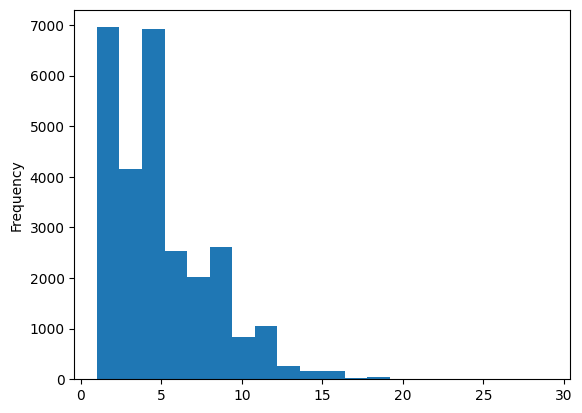

In [43]:
# Sanity check our event counts.
# Should have a min >= 0, 
# mostly small ints
# right-skewed (many low-count bins, few high ones) 
event_counts['count'].plot.hist(bins=20)

In [54]:
len(event_counts)

27735

In [60]:
def reindex_complete_6h_grid(
    event_counts: pd.DataFrame,
    *,
    neighborhoods: Sequence[str],
    start: str | pd.Timestamp,
    end: str | pd.Timestamp,  # exclusive end
    freq: str = "6H",
) -> pd.DataFrame:
    """
    Ensure every neighborhood has a complete 6-hour time grid in [start, end),
    filling missing intervals with count=0.

    Parameters
    ----------
    event_counts:
        DataFrame with columns: neighborhood, interval_start, count
    neighborhoods:
        Neighborhoods to include (and order to use).
    start, end:
        Time bounds: [start, end) (end is exclusive).
    freq:
        Frequency string, default "6H".

    Returns
    -------
    pd.DataFrame
        Columns: neighborhood, interval_start, count
        with complete grid and missing counts filled with 0.
    """
    required = {"neighborhood", "interval_start", "count"}
    missing = required - set(event_counts.columns)
    if missing:
        raise ValueError(f"event_counts missing required columns: {missing}")

    df = event_counts.copy()

    # Normalize dtypes
    df["interval_start"] = pd.to_datetime(df["interval_start"], errors="coerce")
    df["count"] = df["count"].fillna(0).astype("int64")

    # Build the complete 6-hour time index for the requested window
    start_ts = pd.Timestamp(start).floor(freq)
    end_ts = pd.Timestamp(end)

    full_range = pd.date_range(start=start_ts, end=end_ts, freq=freq)
    full_range = full_range[full_range < end_ts]  # enforce [start, end)

    # Build MultiIndex of all neighborhood × interval_start combos
    # Use Categorical so neighborhoods stay in your desired order
    neighborhoods_cat = pd.Categorical(neighborhoods, categories=list(neighborhoods), ordered=False)

    full_index = pd.MultiIndex.from_product(
        [neighborhoods_cat, full_range],
        names=["neighborhood", "interval_start"],
    )

    # Reindex onto the full grid and fill missing counts with 0
    out = (
        df.set_index(["neighborhood", "interval_start"])
          .reindex(full_index, fill_value=0)
          .reset_index()
          .sort_values(["neighborhood", "interval_start"], kind="stable")
          .reset_index(drop=True)
    )

    out["neighborhood"] = out["neighborhood"].astype("category")
    out["count"] = out["count"].astype("int64")

    return out

In [62]:
neighborhoods = ["Mission", "SoMa", "Tenderloin", "Nob Hill", "Ingleside"]

event_counts_full = reindex_complete_6h_grid(
    event_counts,
    neighborhoods=neighborhoods,
    start="2016-01-01",
    end="2020-01-01",   # exclusive
    freq="6h",
)

event_counts_full.head(5)

,neighborhood,interval_start,count
0,Mission,2016-01-01 00:00:00,10
1,Mission,2016-01-01 06:00:00,2
2,Mission,2016-01-01 12:00:00,1
3,Mission,2016-01-01 18:00:00,3
4,Mission,2016-01-02 00:00:00,4


# Feature Engineering

In [66]:
@dataclass(frozen=True)
class TimeFeatureConfig:
    """Config for cyclical encodings."""
    dow_period: int = 7
    hour_period: int = 24


def add_time_features(
    df: pd.DataFrame,
    *,
    ts_col: str = "interval_start",
    config: TimeFeatureConfig = TimeFeatureConfig(),
) -> pd.DataFrame:
    """
    Add basic datetime features + cyclical encodings derived from `ts_col`.

    Adds:
      - year, month, day, dow (0=Mon..6=Sun), hour (0/6/12/18)
      - dow_sin, dow_cos
      - hour_sin, hour_cos
    """
    if ts_col not in df.columns:
        raise ValueError(f"Missing required timestamp column: {ts_col}")

    out = df.copy()
    out[ts_col] = pd.to_datetime(out[ts_col], errors="coerce")

    # Basic parts
    out["year"] = out[ts_col].dt.year.astype("int32")
    out["month"] = out[ts_col].dt.month.astype("int8")
    out["day"] = out[ts_col].dt.day.astype("int8")
    out["dow"] = out[ts_col].dt.dayofweek.astype("int8")  # 0=Mon ... 6=Sun
    out["hour"] = out[ts_col].dt.hour.astype("int8")      # should be 0,6,12,18

    # Cyclical encodings
    # Convert to radians: 2π * value / period
    dow_rad = 2.0 * np.pi * (out["dow"].to_numpy() / config.dow_period)
    hour_rad = 2.0 * np.pi * (out["hour"].to_numpy() / config.hour_period)

    out["dow_sin"] = np.sin(dow_rad)
    out["dow_cos"] = np.cos(dow_rad)
    out["hour_sin"] = np.sin(hour_rad)
    out["hour_cos"] = np.cos(hour_rad)

    return out


In [67]:
# Add time features to our dataframe
# event_counts_full columns: neighborhood, interval_start, count
feat_df = add_time_features(event_counts_full)

feat_df[["neighborhood", "interval_start", "year", "month", "day", "dow", "hour", "dow_sin", "dow_cos", "hour_sin", "hour_cos", "count"]].head()


,neighborhood,interval_start,year,month,day,dow,hour,dow_sin,dow_cos,hour_sin,hour_cos,count
0,Mission,2016-01-01 00:00:00,2016,1,1,4,0,-0.433884,-0.900969,0.000000e+00,1.000000e+00,10
1,Mission,2016-01-01 06:00:00,2016,1,1,4,6,-0.433884,-0.900969,1.000000e+00,6.123234e-17,2
2,Mission,2016-01-01 12:00:00,2016,1,1,4,12,-0.433884,-0.900969,1.224647e-16,-1.000000e+00,1
3,Mission,2016-01-01 18:00:00,2016,1,1,4,18,-0.433884,-0.900969,-1.000000e+00,-1.836970e-16,3
4,Mission,2016-01-02 00:00:00,2016,1,2,5,0,-0.974928,-0.222521,0.000000e+00,1.000000e+00,4


# Preprocessing: ColumnTransformer (OHE Neighborhood + Scale Numeric)

In [86]:
def make_preprocessor(
    *,
    categorical_features: List[str],
    numeric_features: List[str],
    scale_numeric: bool = True,
    ohe_drop: Optional[str] = None,  # e.g. "first" or None
) -> ColumnTransformer:
    """
    Build a ColumnTransformer that:
      - OneHotEncodes categorical features (neighborhood)
      - Optionally scales numeric features (for linear models)
    """
    cat = OneHotEncoder(
        drop=ohe_drop,
        handle_unknown="ignore",
        sparse_output=False,  # sklearn >=1.2
    )

    num = StandardScaler() if scale_numeric else "passthrough"

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", cat, categorical_features),
            ("num", num, numeric_features),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return preprocessor

In [87]:
# Define feature columns
BASE_CATEGORICAL = ["neighborhood"]
BASE_NUMERIC = ["year", "month", "day", "dow_sin", "dow_cos", "hour_sin", "hour_cos"]
TARGET_COL = "count"


# Build Baseline Pipelines (Ridge + HGBR)

In [71]:
def make_ridge_pipeline(
    *,
    ohe_drop: Optional[str] = None,
    alpha: float = 1.0,
    random_state: int = 42,
) -> Pipeline:
    """
    Ridge baseline: OHE + StandardScaler + Ridge.
    """
    pre = make_preprocessor(
        categorical_features=BASE_CATEGORICAL,
        numeric_features=BASE_NUMERIC,
        scale_numeric=True,
        ohe_drop=ohe_drop,
    )

    model = Ridge(alpha=alpha, random_state=random_state)

    return Pipeline(steps=[
        ("preprocess", pre),
        ("model", model),
    ])

In [72]:
def make_hgbr_pipeline(
    *,
    ohe_drop: Optional[str] = None,
    random_state: int = 42,
) -> Pipeline:
    """
    Gradient boosting baseline: OHE + passthrough numeric (no scaling) + HGBR.
    """
    pre = make_preprocessor(
        categorical_features=BASE_CATEGORICAL,
        numeric_features=BASE_NUMERIC,
        scale_numeric=False,
        ohe_drop=ohe_drop,
    )

    model = HistGradientBoostingRegressor(random_state=random_state)

    return Pipeline(steps=[
        ("preprocess", pre),
        ("model", model),
    ])


In [73]:
# Prepary X / y 

# X / y
X = feat_df[BASE_CATEGORICAL + BASE_NUMERIC].copy()
y = feat_df[TARGET_COL].astype("int64")


In [74]:
# Sanity checks
# Check bins are only the expected hours
feat_df["hour"].value_counts().sort_index()

hour
0     7305
6     7305
12    7305
18    7305
Name: count, dtype: int64

In [75]:
# Check dow range
feat_df["dow"].min(), feat_df["dow"].max()

(np.int8(0), np.int8(6))

In [76]:
# Check no NA in features
X.isna().sum()

neighborhood    0
year            0
month           0
day             0
dow_sin         0
dow_cos         0
hour_sin        0
hour_cos        0
dtype: int64

# Store Variables

In [140]:
%store feat_df event_counts_full

Stored 'feat_df' (DataFrame)
Stored 'event_counts_full' (DataFrame)


# Time Aware Test/Train Split

At this point we have:

* event_counts_full
    * columns: neighborhood, interval_start, count
* feat_df = add_time_features(event_counts_full)
* Feature columns already defined
* Target column: count

We will **not**:

* stratify
* shuffle
* group by neighborhood
* use sklearn’s train_test_split

We will do this manually.
1. Sort everything by time
2. Take earliest **85%** of timestamps --> training
3. Take latest **15%** of timestamps --> test
4. Test data must be _strictly later in time_ that training data.

In [77]:
# Sort by time
feat_df = feat_df.sort_values("interval_start").reset_index(drop=True)


In [78]:
# Compute the split point by index
TEST_FRACTION = 0.15

n_samples = len(feat_df)
split_idx = int(n_samples * (1 - TEST_FRACTION))


In [79]:
# Split X and y

X = feat_df[BASE_CATEGORICAL + BASE_NUMERIC]
y = feat_df["count"]

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

In [81]:
X_train.columns

Index(['neighborhood', 'year', 'month', 'day', 'dow_sin', 'dow_cos',
       'hour_sin', 'hour_cos'],
      dtype='object')

In [83]:
# Sanity check time ordering
feat_df["interval_start"].max(), feat_df["interval_start"].min()

(Timestamp('2019-12-31 18:00:00'), Timestamp('2016-01-01 00:00:00'))

In [85]:
# Neighborhood presence. All neighborhoods should be present.
X_train["neighborhood"].value_counts()
X_test["neighborhood"].value_counts()


neighborhood
Mission       877
SoMa          877
Ingleside     877
Tenderloin    876
Nob Hill      876
Name: count, dtype: int64

We do not split per neighborhood, as the model learns neighborhoods as a feature. We want temporal generalization, not neighborhood isolation.

# Why we need DummyRegressor

We predicting counts, per 6-hour bin, per neighborhood. Counts have:
* Central tendency (average level)
* Big variance by neighborhood and time

Mode can look good, but just basically guess something near average. `DummyRegressor` gives performance of that exact behavior.

* If Ridge/HBR barely beats DummyRegressor:
    * Features/model are not learning much signal, or we are over-regularized, or you have leakage elsewhere.
* If Ridge / HGBR clearly beats DummyRegressor:
    * Model is extracting useful predictive structure.
 
* RMSE / MAE
    * Set the "floor." Your model must reduce RMSE/MAE relative to dummy, or it not worth it.
 
Mean is the correct dummy since we want to "predict the typical count."

We must fit `DummyRegressor` on TRAIN only to prevent leakage. Fit on `y_train` and evaluate on `y_test`.

The "precision" takeaway is that `DummyRegressor` is a control group. 
* **Control**: predict the mean always (DummyRegressor)
* **Treatment**: your ML model (Ridge / HGBR)

In [89]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)          # X_train is ignored, but required by API
y_pred_train = dummy.predict(X_train)
y_pred_test  = dummy.predict(X_test)

In [94]:
def regression_metrics(
    y_true: np.ndarray | pd.Series,
    y_pred: np.ndarray,
) -> dict[str, float]:
    """
    Compute regression metrics used in the assignment.
    """
    return {
        "RMSE": mean_squared_error(y_true, y_pred, multioutput='raw_values'),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MaxError": max_error(y_true, y_pred),
    }


In [ ]:
mean_squared_error?

In [95]:
# Evaluate metrics
dummy_train_metrics = regression_metrics(y_train, y_pred_train)
dummy_test_metrics  = regression_metrics(y_test, y_pred_test)

dummy_train_metrics, dummy_test_metrics


({'RMSE': array([10.06294864]),
  'MAE': 2.517600949761475,
  'MaxError': 19.437250875709626},
 {'RMSE': array([13.05715407]),
  'MAE': 2.7677905804848297,
  'MaxError': 24.437250875709626})

In [96]:
# Sanity check what dummy predicts
dummy.constant_

array([[4.56274912]])

In [97]:
# ...`dummy.constant_` should equal y_train.mean()
y_train.mean()

np.float64(4.562749124290373)

# Ridge Regressor

In [99]:
# ----------------------------
# Ridge pipeline
# ----------------------------
# Preprocessor: OHE for neighborhood, scale numeric for Ridge
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", drop=None, sparse_output=False), BASE_CATEGORICAL),
        ("num", StandardScaler(), BASE_NUMERIC),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

ridge = Ridge(alpha=1.0, random_state=42)

ridge_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", ridge),
])


# ----------------------------
# Fit + predict
# ----------------------------
ridge_pipe.fit(X_train, y_train)

y_train_pred_ridge = ridge_pipe.predict(X_train)
y_test_pred_ridge  = ridge_pipe.predict(X_test)


# ----------------------------
# Evaluate
# ----------------------------
ridge_train_metrics = regression_metrics(y_train, y_train_pred_ridge)
ridge_test_metrics  = regression_metrics(y_test, y_test_pred_ridge)

ridge_train_metrics, ridge_test_metrics


({'RMSE': array([5.45464911]),
  'MAE': 1.8017087150401707,
  'MaxError': 15.816258424819347},
 {'RMSE': array([6.5965887]),
  'MAE': 1.8889425206844308,
  'MaxError': 20.7217611521854})

In [100]:
# Assumes you already computed these from the DummyRegressor step:
# dummy_train_metrics, dummy_test_metrics

results = pd.DataFrame(
    [
        {
            "Model": "DummyRegressor (mean)",
            "Train RMSE": dummy_train_metrics["RMSE"],
            "Test RMSE": dummy_test_metrics["RMSE"],
            "Train MAE": dummy_train_metrics["MAE"],
            "Test MAE": dummy_test_metrics["MAE"],
            "Train MaxError": dummy_train_metrics["MaxError"],
            "Test MaxError": dummy_test_metrics["MaxError"],
        },
        {
            "Model": "Ridge",
            "Train RMSE": ridge_train_metrics["RMSE"],
            "Test RMSE": ridge_test_metrics["RMSE"],
            "Train MAE": ridge_train_metrics["MAE"],
            "Test MAE": ridge_test_metrics["MAE"],
            "Train MaxError": ridge_train_metrics["MaxError"],
            "Test MaxError": ridge_test_metrics["MaxError"],
        },
    ]
).set_index("Model")

results


,Train RMSE,Test RMSE,Train MAE,Test MAE,Train MaxError,Test MaxError
Model,,,,,,
DummyRegressor (mean),[10.062948644755545],[13.057154069017656],2.517601,2.767791,19.437251,24.437251
Ridge,[5.454649114661952],[6.596588700064784],1.801709,1.888943,15.816258,20.721761


In [112]:
# Reconstruct the rows corresponding to X_test, including interval_start
# This works even if X_test does not contain interval_start.
test_rows = feat_df.loc[X_test.index, ["interval_start", "neighborhood", "count"]].copy()

# Attach predictions with explicit index alignment
test_rows["pred_ridge"] = pd.Series(np.asarray(y_test_pred_ridge), index=X_test.index)

#  Show a few chronological examples
test_rows = test_rows.sort_values("interval_start")
test_rows.head(15)

,interval_start,neighborhood,count,pred_ridge
24837,2019-05-26 18:00:00,Ingleside,3,2.257002
24838,2019-05-26 18:00:00,Mission,4,3.780552
24839,2019-05-26 18:00:00,SoMa,11,6.628379
24840,2019-05-27 00:00:00,Tenderloin,7,4.940664
24841,2019-05-27 00:00:00,Mission,2,1.840398
24842,2019-05-27 00:00:00,SoMa,2,4.688224
24843,2019-05-27 00:00:00,Ingleside,0,0.316848
24844,2019-05-27 00:00:00,Nob Hill,5,2.013113
24845,2019-05-27 06:00:00,Mission,2,3.292863
24846,2019-05-27 06:00:00,Ingleside,3,1.769312


In [111]:
y_test_pred_ridge

array([2.2570017 , 3.78055243, 6.62837851, ..., 3.66091187, 6.7611774 ,
       2.13736114])

In [113]:
def build_pred_frame(
    feat_df: pd.DataFrame,
    X_index: pd.Index,
    y_true: pd.Series,
    y_pred: np.ndarray | pd.Series,
    *,
    y_col: str = "count",
    pred_col: str = "pred",
) -> pd.DataFrame:
    """
    Return a tidy frame with interval_start, neighborhood, y_true, y_pred aligned by index.
    """
    out = feat_df.loc[X_index, ["interval_start", "neighborhood", y_col]].copy()
    out = out.rename(columns={y_col: "y_true"})
    out[pred_col] = pd.Series(np.asarray(y_pred), index=X_index)
    return out.sort_values(["neighborhood", "interval_start"], kind="stable").reset_index(drop=True)


test_preds = build_pred_frame(
    feat_df=feat_df,
    X_index=X_test.index,
    y_true=y_test,
    y_pred=y_test_pred_ridge,
    pred_col="y_pred",
)

# Last ~30 intervals PER neighborhood
last30_per_neighborhood = (
    test_preds.sort_values("interval_start")
              .groupby("neighborhood", as_index=False, observed=True)
              .tail(30)
              .sort_values(["neighborhood", "interval_start"])
)

last30_per_neighborhood


,interval_start,neighborhood,y_true,y_pred
847,2019-12-24 12:00:00,Mission,5,5.198694
848,2019-12-24 18:00:00,Mission,3,3.746229
849,2019-12-25 00:00:00,Mission,1,1.916051
850,2019-12-25 06:00:00,Mission,4,3.368515
851,2019-12-25 12:00:00,Mission,5,5.256979
...,...,...,...,...
4378,2019-12-30 18:00:00,Ingleside,1,2.124712
4379,2019-12-31 00:00:00,Ingleside,1,0.248897
4380,2019-12-31 06:00:00,Ingleside,3,1.701362
4381,2019-12-31 12:00:00,Ingleside,3,3.589826


## Scatterplot Actual vs. Predicted

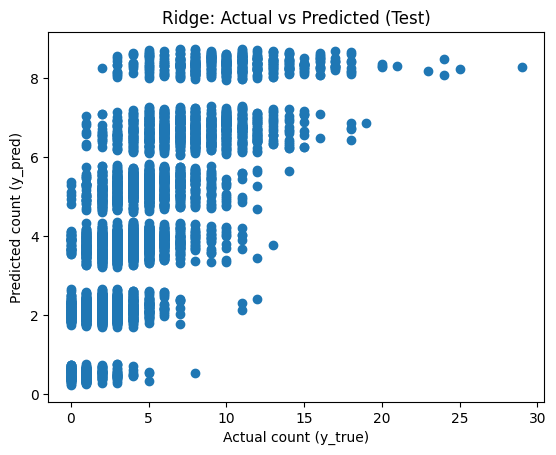

In [115]:
plt.figure()
plt.scatter(test_preds["y_true"], test_preds["y_pred"])
plt.xlabel("Actual count (y_true)")
plt.ylabel("Predicted count (y_pred)")
plt.title("Ridge: Actual vs Predicted (Test)")
plt.show()


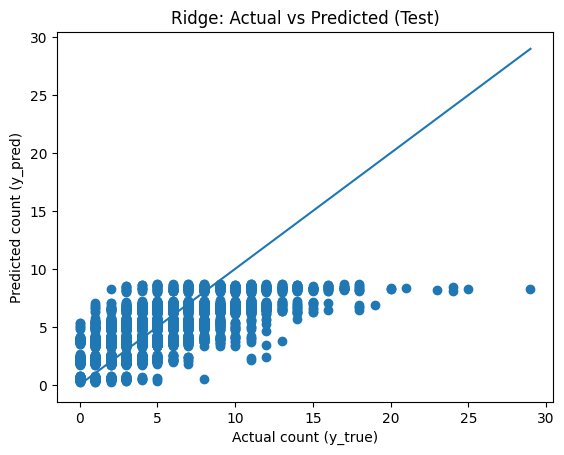

In [116]:
plt.figure()
plt.scatter(test_preds["y_true"], test_preds["y_pred"])
m = min(test_preds["y_true"].min(), test_preds["y_pred"].min())
M = max(test_preds["y_true"].max(), test_preds["y_pred"].max())
plt.plot([m, M], [m, M])  # diagonal reference
plt.xlabel("Actual count (y_true)")
plt.ylabel("Predicted count (y_pred)")
plt.title("Ridge: Actual vs Predicted (Test)")
plt.show()


## Residuuals Over Time (Test Set)

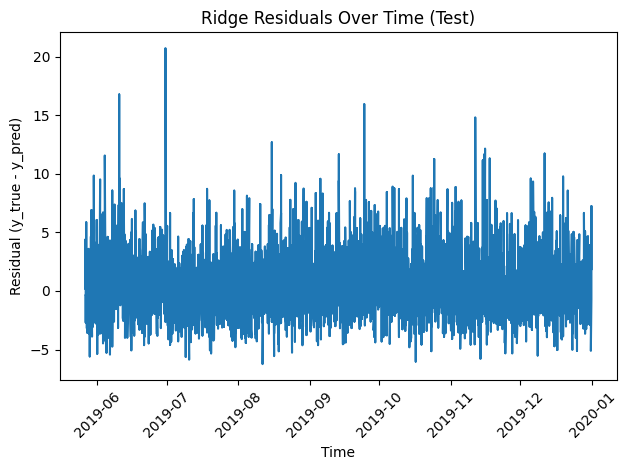

In [117]:
test_preds_time = test_preds.sort_values("interval_start").copy()
test_preds_time["residual"] = test_preds_time["y_true"] - test_preds_time["y_pred"]

plt.figure()
plt.plot(test_preds_time["interval_start"], test_preds_time["residual"])
plt.xlabel("Time")
plt.ylabel("Residual (y_true - y_pred)")
plt.title("Ridge Residuals Over Time (Test)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


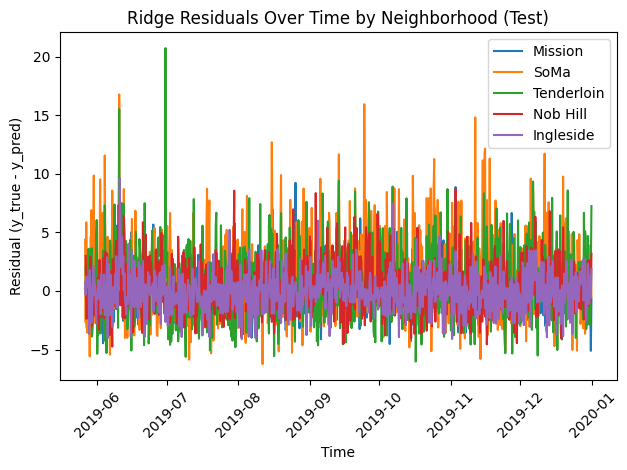

In [118]:
# Per neighborhood
plt.figure()
for nbhd, g in test_preds_time.groupby("neighborhood", observed=True):
    plt.plot(g["interval_start"], g["residual"], label=str(nbhd))
plt.xlabel("Time")
plt.ylabel("Residual (y_true - y_pred)")
plt.title("Ridge Residuals Over Time by Neighborhood (Test)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## Over/Underfitting Check

In [119]:
rows = [
    {
        "Model": "Ridge",
        "Train RMSE": ridge_train_metrics["RMSE"],
        "Test RMSE": ridge_test_metrics["RMSE"],
        "Train MAE": ridge_train_metrics["MAE"],
        "Test MAE": ridge_test_metrics["MAE"],
        "Train MaxError": ridge_train_metrics["MaxError"],
        "Test MaxError": ridge_test_metrics["MaxError"],
    }
]

# Add dummy row if you have it
if "dummy_train_metrics" in globals() and "dummy_test_metrics" in globals():
    rows.insert(0, {
        "Model": "DummyRegressor (mean)",
        "Train RMSE": dummy_train_metrics["RMSE"],
        "Test RMSE": dummy_test_metrics["RMSE"],
        "Train MAE": dummy_train_metrics["MAE"],
        "Test MAE": dummy_test_metrics["MAE"],
        "Train MaxError": dummy_train_metrics["MaxError"],
        "Test MaxError": dummy_test_metrics["MaxError"],
    })

pd.DataFrame(rows).set_index("Model")


,Train RMSE,Test RMSE,Train MAE,Test MAE,Train MaxError,Test MaxError
Model,,,,,,
DummyRegressor (mean),[10.062948644755545],[13.057154069017656],2.517601,2.767791,19.437251,24.437251
Ridge,[5.454649114661952],[6.596588700064784],1.801709,1.888943,15.816258,20.721761


Interpreting results

* Dummy Test RMSE = 13.06, Ridge Test RMSE = 6.60 --> 50% reduction in RMSE
* Dummy Test MAE = 2.77, Ridge Test MAE = 1.89 --> 32% reduction in typical absolute error. Ridge is learning structure
* Overfitting = (Test RMSE - Train RMSE )/ Train RMSE --> 1.15 / 5.45 ~ 21%.
* MAE ~ 1.9 --> On average, we are off by ~2 events per 6-hour window.
    * If counts are 1-3, this is large
    * If counts are 5-15, this is moderat
    * If counts are 20-40, this is small
* Large MaxError indicates there is a bin where we missed by ~ 21 events.
    * Linear models smooth
    * Emergency spikes are nonlinear
    * Rare surges dominate max error.
    * Why assignment suggests using "more powerful ML models."  

In [120]:
feat_df['count'].describe()

count    29220.000000
mean         4.635010
std          3.241484
min          0.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         29.000000
Name: count, dtype: float64

# HistGradientBoosting Regressor

In [121]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, max_error
from sklearn.inspection import permutation_importance

In [127]:
# ----------------------------
# Metrics helpers
# ----------------------------
def rmse(y_true: np.ndarray | pd.Series, y_pred: np.ndarray) -> float:
    return mean_squared_error(y_true, y_pred, )

def mae(y_true: np.ndarray | pd.Series, y_pred: np.ndarray) -> float:
    return mean_absolute_error(y_true, y_pred)

def maxerr(y_true: np.ndarray | pd.Series, y_pred: np.ndarray) -> float:
    return max_error(y_true, y_pred)

def evaluate_regression(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    return {"RMSE": rmse(y_true, y_pred), "MAE": mae(y_true, y_pred), "MaxError": maxerr(y_true, y_pred)}



In [124]:
preprocess_hgbr = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", drop=None, sparse_output=False), BASE_CATEGORICAL),
        ("num", "passthrough", BASE_NUMERIC),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

hgbr = HistGradientBoostingRegressor(
    random_state=42,
    loss="squared_error",
)

hgbr_pipe = Pipeline(steps=[
    ("preprocess", preprocess_hgbr),
    ("model", hgbr),
])


# ----------------------------
# Time-series CV setup
# ----------------------------
tscv = TimeSeriesSplit(n_splits=5)


# ----------------------------
# Fast randomized hyperparam search
# ----------------------------
param_distributions = {
    "model__learning_rate": [0.03, 0.05, 0.08, 0.1, 0.15],
    "model__max_depth": [None, 3, 5, 7, 9],
    "model__max_leaf_nodes": [15, 31, 63, 127],
    "model__min_samples_leaf": [10, 20, 50, 100],
    "model__l2_regularization": [0.0, 0.01, 0.1, 1.0],
}

search = RandomizedSearchCV(
    estimator=hgbr_pipe,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="neg_root_mean_squared_error",  # RMSE (lower is better)
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

search.fit(X_train, y_train)

best_hgbr_pipe = search.best_estimator_
best_params = search.best_params_
best_cv_rmse = -search.best_score_

best_params, best_cv_rmse

Fitting 5 folds for each of 20 candidates, totalling 100 fits


({'model__min_samples_leaf': 20,
  'model__max_leaf_nodes': 15,
  'model__max_depth': 9,
  'model__learning_rate': 0.03,
  'model__l2_regularization': 0.0},
 np.float64(2.269651626434992))

In [125]:
# ----------------------------
# CV summary: mean ± std for RMSE + MAE
# ----------------------------
cv_results = pd.DataFrame(search.cv_results_)

# RMSE from scoring (neg_root_mean_squared_error)
rmse_mean = -cv_results.loc[cv_results["rank_test_score"] == 1, "mean_test_score"].iloc[0]
rmse_std  =  cv_results.loc[cv_results["rank_test_score"] == 1, "std_test_score"].iloc[0]

# Compute MAE across folds using cross-val predictions is more work;
# simplest: refit best model per fold manually.
def cv_mae_for_best_model(
    model: Pipeline,
    X: pd.DataFrame,
    y: pd.Series,
    splitter: TimeSeriesSplit,
) -> tuple[float, float]:
    maes: list[float] = []
    for train_idx, val_idx in splitter.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        m = model
        m.fit(X_tr, y_tr)
        pred = m.predict(X_val)
        maes.append(mean_absolute_error(y_val, pred))
    return float(np.mean(maes)), float(np.std(maes))

best_model_for_cv = best_hgbr_pipe
mae_mean, mae_std = cv_mae_for_best_model(best_model_for_cv, X_train, y_train, tscv)

cv_summary = pd.DataFrame(
    {
        "Metric": ["RMSE", "MAE"],
        "CV Mean": [rmse_mean, mae_mean],
        "CV Std": [rmse_std, mae_std],
    }
)

cv_summary


,Metric,CV Mean,CV Std
0,RMSE,2.269652,0.036074
1,MAE,1.749785,0.014545


In [128]:
# ----------------------------
# Final fit on full train, eval on train/test
# ----------------------------
best_hgbr_pipe.fit(X_train, y_train)

y_train_pred_hgbr = best_hgbr_pipe.predict(X_train)
y_test_pred_hgbr  = best_hgbr_pipe.predict(X_test)

hgbr_train_metrics = evaluate_regression(y_train, y_train_pred_hgbr)
hgbr_test_metrics  = evaluate_regression(y_test, y_test_pred_hgbr)

hgbr_train_metrics, hgbr_test_metrics


({'RMSE': 4.982262908608332,
  'MAE': 1.724208277943284,
  'MaxError': 16.239355026020824},
 {'RMSE': 6.222853815760959,
  'MAE': 1.8369427221214698,
  'MaxError': 21.230866249347258})

In [129]:
# ----------------------------
# Add to your comparison table (Dummy / Ridge / HGBR)
# Assumes you already have dummy_* and ridge_* metrics from Phase 4.
# ----------------------------
rows = []

if "dummy_train_metrics" in globals() and "dummy_test_metrics" in globals():
    rows.append({
        "Model": "DummyRegressor (mean)",
        "Train RMSE": dummy_train_metrics["RMSE"],
        "Test RMSE": dummy_test_metrics["RMSE"],
        "Train MAE": dummy_train_metrics["MAE"],
        "Test MAE": dummy_test_metrics["MAE"],
        "Train MaxError": dummy_train_metrics["MaxError"],
        "Test MaxError": dummy_test_metrics["MaxError"],
    })

if "ridge_train_metrics" in globals() and "ridge_test_metrics" in globals():
    rows.append({
        "Model": "Ridge",
        "Train RMSE": ridge_train_metrics["RMSE"],
        "Test RMSE": ridge_test_metrics["RMSE"],
        "Train MAE": ridge_train_metrics["MAE"],
        "Test MAE": ridge_test_metrics["MAE"],
        "Train MaxError": ridge_train_metrics["MaxError"],
        "Test MaxError": ridge_test_metrics["MaxError"],
    })

rows.append({
    "Model": "HistGradientBoostingRegressor",
    "Train RMSE": hgbr_train_metrics["RMSE"],
    "Test RMSE": hgbr_test_metrics["RMSE"],
    "Train MAE": hgbr_train_metrics["MAE"],
    "Test MAE": hgbr_test_metrics["MAE"],
    "Train MaxError": hgbr_train_metrics["MaxError"],
    "Test MaxError": hgbr_test_metrics["MaxError"],
})

results_all = pd.DataFrame(rows).set_index("Model")
results_all


,Train RMSE,Test RMSE,Train MAE,Test MAE,Train MaxError,Test MaxError
Model,,,,,,
DummyRegressor (mean),[10.062948644755545],[13.057154069017656],2.517601,2.767791,19.437251,24.437251
Ridge,[5.454649114661952],[6.596588700064784],1.801709,1.888943,15.816258,20.721761
HistGradientBoostingRegressor,4.982263,6.222854,1.724208,1.836943,16.239355,21.230866


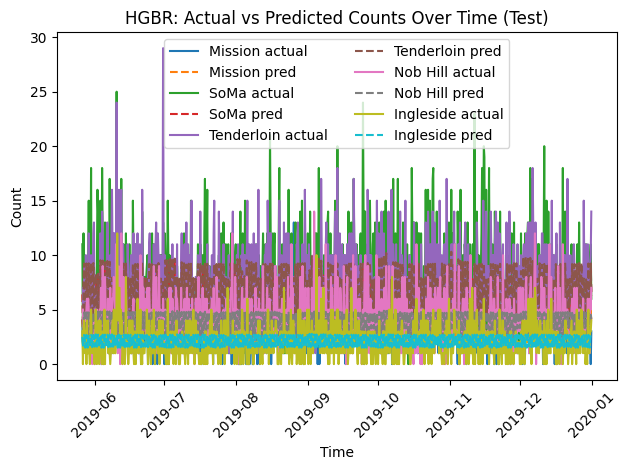

In [130]:
# ----------------------------
# Plots: Predictions vs Actual over time (test)
# Robust alignment using feat_df + X_test.index
# ----------------------------
import matplotlib.pyplot as plt

test_plot_df = feat_df.loc[X_test.index, ["interval_start", "neighborhood", "count"]].copy()
test_plot_df["pred_hgbr"] = pd.Series(np.asarray(y_test_pred_hgbr), index=X_test.index)
test_plot_df = test_plot_df.sort_values(["neighborhood", "interval_start"])

# Plot per neighborhood (time series)
plt.figure()
for nbhd, g in test_plot_df.groupby("neighborhood", observed=True):
    # show actual and predicted as lines (can be busy but acceptable for baseline)
    plt.plot(g["interval_start"], g["count"], label=f"{nbhd} actual")
    plt.plot(g["interval_start"], g["pred_hgbr"], label=f"{nbhd} pred", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Count")
plt.title("HGBR: Actual vs Predicted Counts Over Time (Test)")
plt.xticks(rotation=45)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


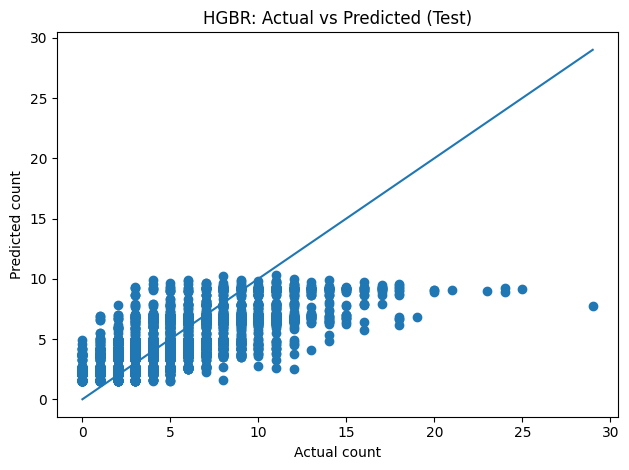

In [131]:
# ----------------------------
# Plots: Combined scatter y_true vs y_pred (test)
# ----------------------------
plt.figure()
plt.scatter(test_plot_df["count"], test_plot_df["pred_hgbr"])
m = min(test_plot_df["count"].min(), test_plot_df["pred_hgbr"].min())
M = max(test_plot_df["count"].max(), test_plot_df["pred_hgbr"].max())
plt.plot([m, M], [m, M])
plt.xlabel("Actual count")
plt.ylabel("Predicted count")
plt.title("HGBR: Actual vs Predicted (Test)")
plt.tight_layout()
plt.show()


In [138]:
# ----------------------------
# Permutation importance (on test set)
# NOTE: requires feature names; we can get them from the preprocessor.
# ----------------------------
# Get transformed feature names
feature_names = best_hgbr_pipe.named_steps["preprocess"].get_feature_names_out()

# These are the columns permutation_importance is permuting
input_feature_names = list(X_test.columns)

# Compute permutation importance on test set
perm = permutation_importance(
    best_hgbr_pipe,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="neg_root_mean_squared_error",
)

importances = pd.DataFrame(
    {
        "feature": input_feature_names,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values("importance_mean", ascending=False)

importances.head(15)


,feature,importance_mean,importance_std
0,neighborhood,1.285093,0.024109
7,hour_cos,0.658246,0.015816
4,dow_sin,0.052321,0.004946
6,hour_sin,0.010668,0.001889
5,dow_cos,0.004229,0.001601
2,month,0.000645,0.000496
1,year,0.000000,0.000000
3,day,-0.000036,0.002011


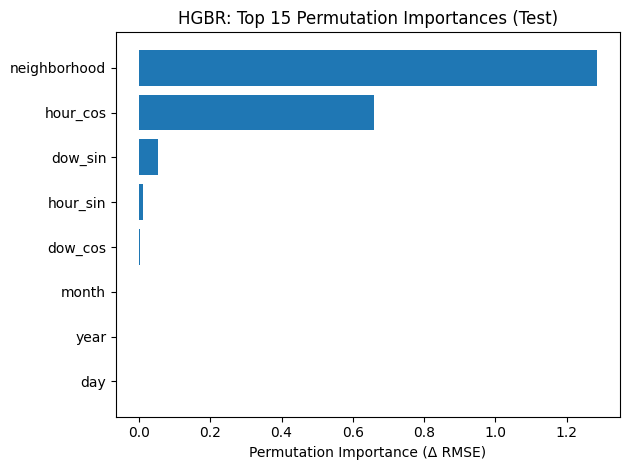

In [139]:
# Quick bar plot of top-k importances (optional)
top_k = 15
top = importances.head(top_k)

plt.figure()
plt.barh(top["feature"][::-1], top["importance_mean"][::-1])
plt.xlabel("Permutation Importance (Δ RMSE)")
plt.title(f"HGBR: Top {top_k} Permutation Importances (Test)")
plt.tight_layout()
plt.show()


* TimeSeriesSplit assumes rows are already time-ordered. If you created X_train from sorted feat_df, you're fine.
* The MAE CV summary is computed by manual fold loop (simple + correct).
* Permutation importance can be slow; start with n_repeats=5 if needed.

In [137]:
len(feature_names)

12